In [1]:
import requests
import pandas as pd
import time

all_data = []

for i in range(1, 51):  # Pokemon ID 1 to 50
    url = f"https://pokeapi.co/api/v2/pokemon/{i}"
    response = requests.get(url)
    data = response.json()
    
    all_data.append({
        'id': data['id'],
        'name': data['name'],
        'height': data['height'],
        'weight': data['weight'],
        'base_experience': data['base_experience'],
        'hp': data['stats'][0]['base_stat'],
        'attack': data['stats'][1]['base_stat'],
        'defense': data['stats'][2]['base_stat'],
        'special_attack': data['stats'][3]['base_stat'],
        'special_defense': data['stats'][4]['base_stat'],
        'speed': data['stats'][5]['base_stat'],
        'type1': data['types'][0]['type']['name'],
        'type2': data['types'][1]['type']['name'] if len(data['types']) > 1 else 'None',
        'abilities': ', '.join([a['ability']['name'] for a in data['abilities']])
    })
    
    time.sleep(0.3)  # API ko overload mat karo
    print(f"Done: {data['name']} ✅")

df = pd.DataFrame(all_data)
df.to_csv('pokemon_stats.csv', index=False)
print(f"\nTotal: {len(df)} Pokemon saved!")
print(df.head())

Done: bulbasaur ✅
Done: ivysaur ✅
Done: venusaur ✅
Done: charmander ✅
Done: charmeleon ✅
Done: charizard ✅
Done: squirtle ✅
Done: wartortle ✅
Done: blastoise ✅
Done: caterpie ✅
Done: metapod ✅
Done: butterfree ✅
Done: weedle ✅
Done: kakuna ✅
Done: beedrill ✅
Done: pidgey ✅
Done: pidgeotto ✅
Done: pidgeot ✅
Done: rattata ✅
Done: raticate ✅
Done: spearow ✅
Done: fearow ✅
Done: ekans ✅
Done: arbok ✅
Done: pikachu ✅
Done: raichu ✅
Done: sandshrew ✅
Done: sandslash ✅
Done: nidoran-f ✅
Done: nidorina ✅
Done: nidoqueen ✅
Done: nidoran-m ✅
Done: nidorino ✅
Done: nidoking ✅
Done: clefairy ✅
Done: clefable ✅
Done: vulpix ✅
Done: ninetales ✅
Done: jigglypuff ✅
Done: wigglytuff ✅
Done: zubat ✅
Done: golbat ✅
Done: oddish ✅
Done: gloom ✅
Done: vileplume ✅
Done: paras ✅
Done: parasect ✅
Done: venonat ✅
Done: venomoth ✅
Done: diglett ✅

Total: 50 Pokemon saved!
   id        name  height  weight  base_experience  hp  attack  defense  \
0   1   bulbasaur       7      69               64  45      49    

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('pokemon_stats.csv')
sns.set_theme(style="darkgrid")
print(df.head())

   id        name  height  weight  base_experience  hp  attack  defense  \
0   1   bulbasaur       7      69               64  45      49       49   
1   2     ivysaur      10     130              142  60      62       63   
2   3    venusaur      20    1000              236  80      82       83   
3   4  charmander       6      85               62  39      52       43   
4   5  charmeleon      11     190              142  58      64       58   

   special_attack  special_defense  speed  type1   type2  \
0              65               65     45  grass  poison   
1              80               80     60  grass  poison   
2             100              100     80  grass  poison   
3              60               50     65   fire     NaN   
4              80               65     80   fire     NaN   

               abilities  
0  overgrow, chlorophyll  
1  overgrow, chlorophyll  
2  overgrow, chlorophyll  
3     blaze, solar-power  
4     blaze, solar-power  


C:\Users\hp\AppData\Local\Temp\ipykernel_17968\853999868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_attack, x='name', y='attack', palette='flare')


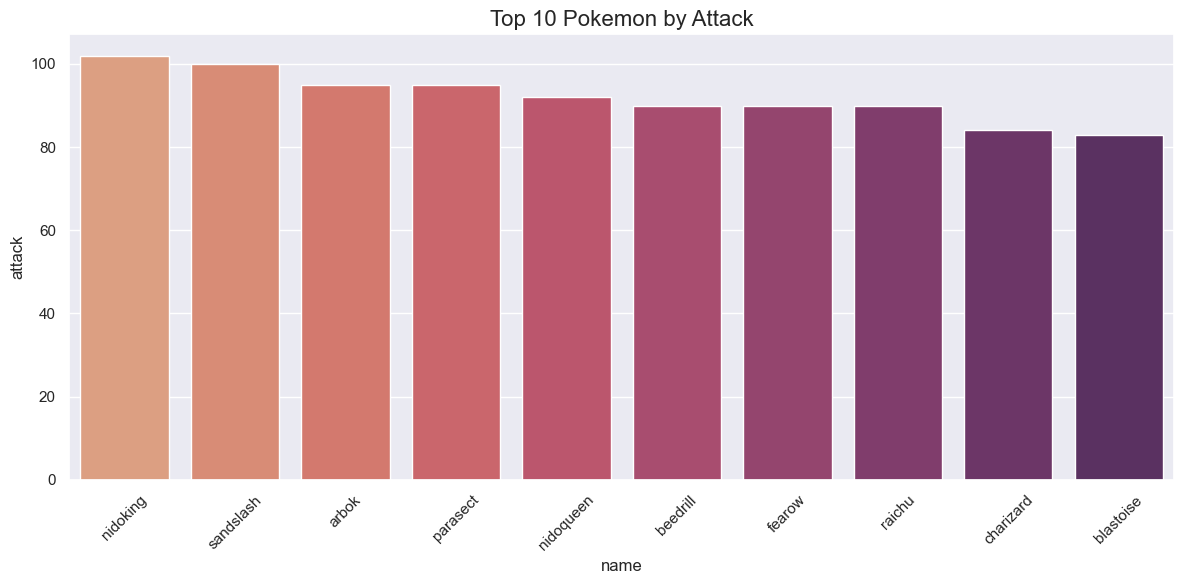

In [3]:
plt.figure(figsize=(12, 6))
top_attack = df.nlargest(10, 'attack')
sns.barplot(data=top_attack, x='name', y='attack', palette='flare')
plt.title('Top 10 Pokemon by Attack', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_attack.png')
plt.show()

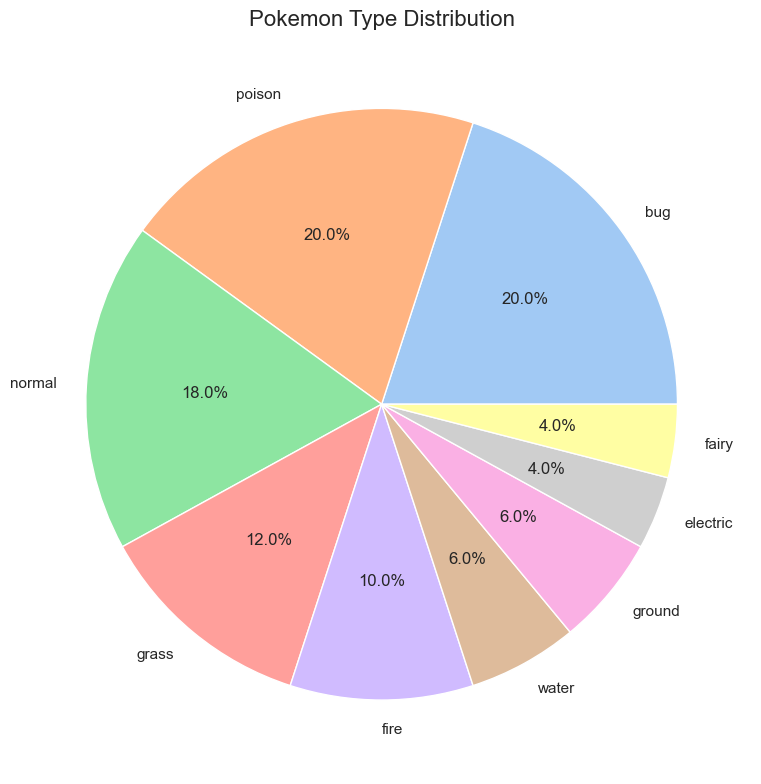

In [4]:
plt.figure(figsize=(8, 8))
type_counts = df['type1'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Pokemon Type Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('type_distribution.png')
plt.show()

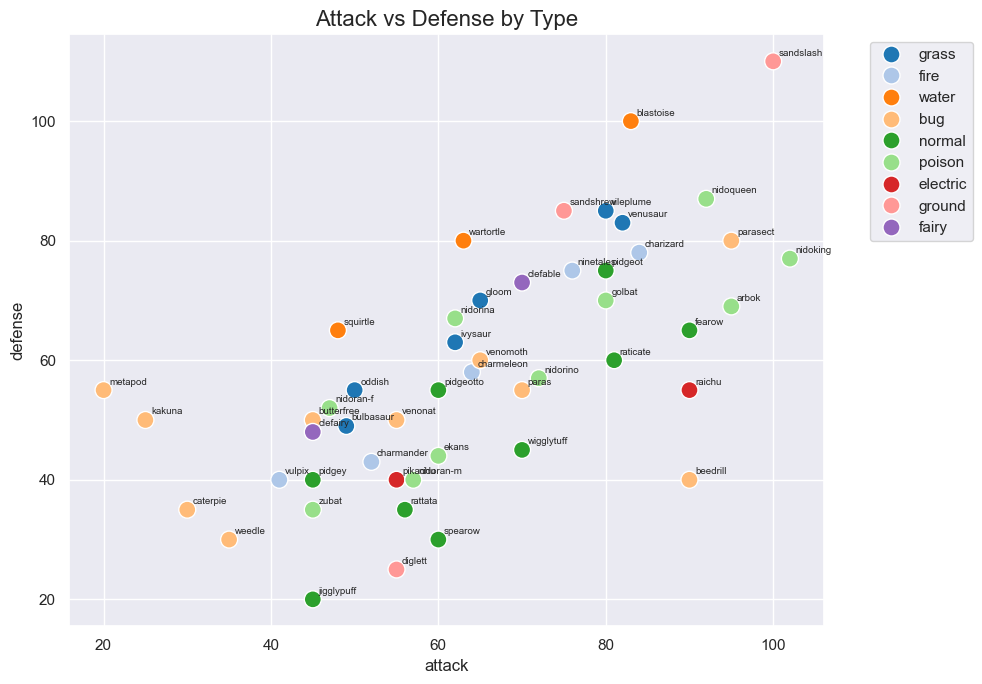

In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='attack', y='defense',
                hue='type1', s=150, palette='tab20')
for i, row in df.iterrows():
    plt.annotate(row['name'], (row['attack'], row['defense']),
                 fontsize=7, xytext=(4, 4),
                 textcoords='offset points')
plt.title('Attack vs Defense by Type', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('attack_vs_defense.png')
plt.show()

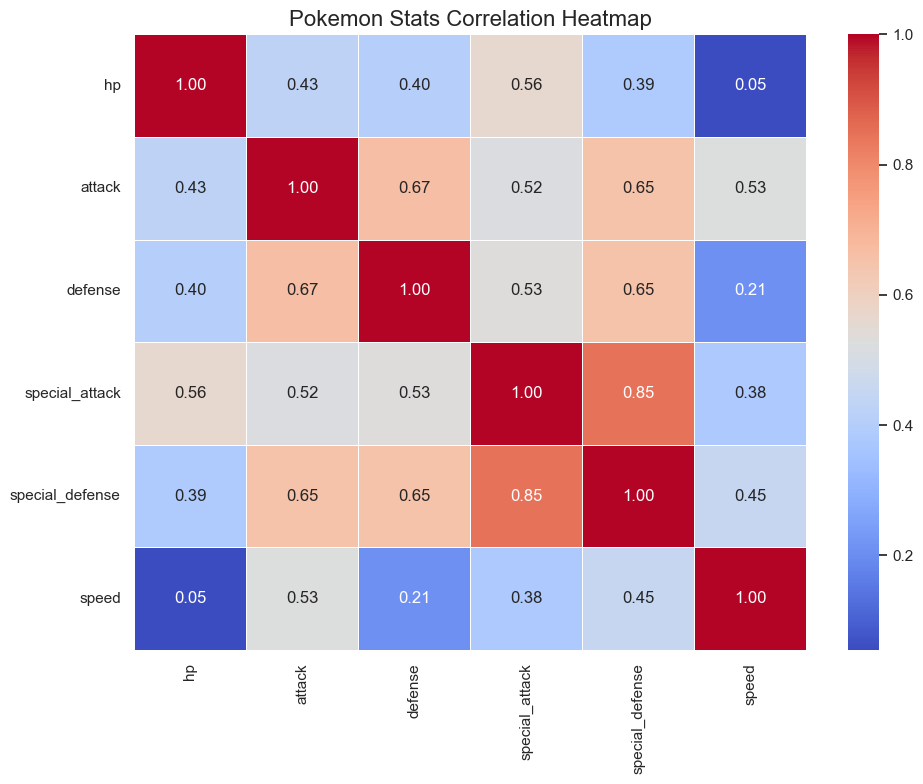

In [6]:
plt.figure(figsize=(10, 8))
stats_cols = ['hp', 'attack', 'defense', 
              'special_attack', 'special_defense', 'speed']
sns.heatmap(df[stats_cols].corr(), annot=True, 
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pokemon Stats Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

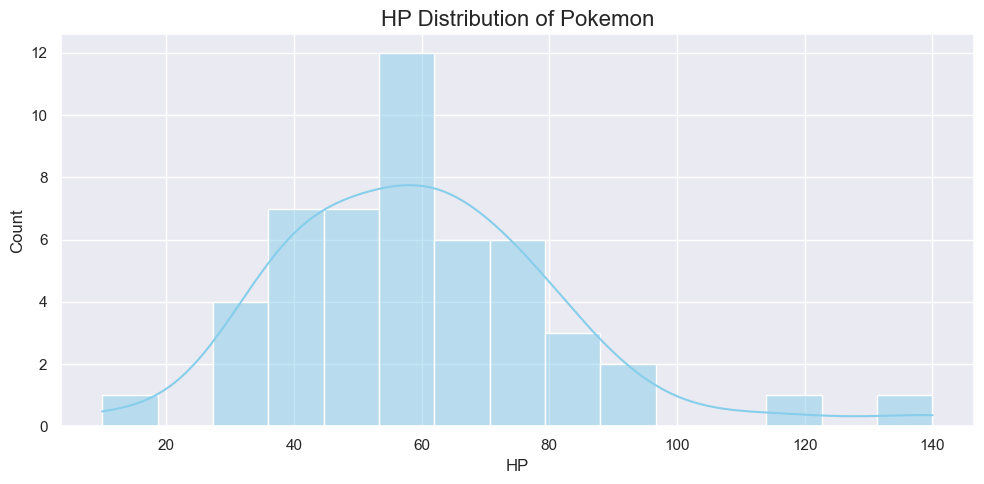

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['hp'], bins=15, kde=True, color='skyblue')
plt.title('HP Distribution of Pokemon', fontsize=16)
plt.xlabel('HP')
plt.tight_layout()
plt.savefig('hp_distribution.png')
plt.show()